

<img height="300" src="https://ih1.redbubble.net/image.1508859238.3835/flat,750x,075,f-pad,750x1000,f8f8f8.u17.jpg" />

# Anatomy of a Chatbot

Key ideas:
- All recent developments in "AI" build on the same [Transformer architecture](https://ig.ft.com/generative-ai/) that we've discussed before.
- Nearly all new capabilities are forms of prompt engineering.
- They are all modifications of the text sent to the model.  


## Fine-Tuning for Chat

The scientists who invented the Transformer were working on translation ([Lewis-Kraus](https://www.nytimes.com/2016/12/14/magazine/the-great-ai-awakening.html)). During training, the model learns a numerical representation of the text, an encoding, that can then be decoded into text in another language. The job wasn't manually outlining steps for how to get from language A to language B, but rather automatically learning an intermediate representation that could turn text in one language into another language. It was a question of compressing the information in text into something independent of the language in which it was originally written. For the translation task, the original Transformer followed an *encoder-decoder architecture*.

At about the same time, a group of researchers at OpenAI began to work on a model focused on the *generative decoder*. In 2019, they released Generative Pre-trained Transformer-2 (GPT-2)

In [ ]:
from transformers import pipeline

generator = pipeline('text-generation', model='gpt2')
output = generator("Where can I park my bike near Firestone Library?", max_length=200, truncation=True, num_return_sequences=1)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_length', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [ ]:
from rich import print
for sent in output:
    print(sent['generated_text'])

Where can I park my bike near Firestone Library? - It's possible to park your bike near the Firestone Library. It 
is available on all park trails. (There is a bike parking lot by the library on the north side of the building.) 
This bike parking lot is open to the public only in the summer. If you need a bike parking lot, call 
1-866-937-7888.

- It's possible to park your bike near the Firestone Library. It is available on all park trails. (There is a bike 
parking lot by the library on the north side of the building.) This bike parking lot is open to the public only in 
the summer. If you need a bike parking lot, call 1-866-937-7888. How long can I park my bike near the Firestone 
Library? - You can park your bike in the library at any time. The library will close on weekends or holidays and 
you can park your bike at any time.

- You can park your bike in the library at any time. The library will close on weekends or holidays and you can 
park your bike at any time. Can I park my bike by bike? - Yes. The library will close on weekends or holidays and 
you can park your bike by bike. You can park

A group of researchers from the University of Amsterdam conducted a "Turing Test" to see if people could tell the difference between a poem written by a human or GPT-2.

> Nils Köbis and Luca D. Mossink, "Artificial intelligence versus Maya Angelou: Experimental evidence that people cannot differentiate AI-generated from human-written poetry"
https://www.sciencedirect.com/science/article/pii/S0747563220303034?via%3Dihub

Try it yourself, can you tell that the following was generated by GPT-2?

In [ ]:
poem = generator("The following is my favorite poem: ", max_length=200, truncation=True, num_return_sequences=1)
for line in poem:
    print(line['generated_text'])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The following is my favorite poem:  I will take over her, but I dare not.  If her only purpose is to take me down, 
then we would be at war, so who would you think would fight me? Do you know the name of the enemy?  I mean, you 
want to destroy me anyway, and how can you?  Well, I'll use my powers to do my best against you, and then I will 
call on you so you wouldn't think I'm an old fashioned hero.  Now when I call on you, you will think that the 
enemy's gonna believe me, but you won't.  Then they should be able to take me if they want.  And their own children
are too young.
Now the reason that you think I am evil is because my powers are very powerful, but my powers are much weaker.  I 
have to do as you say, and I

Like the BERT model, GPT-2 and 3 (June 2020) were text-continuation machines. Given a short start sequence, they could continue writing *ad infinitum*. Matthew Kirschenbaum warns of the dangers that come with this ability to create limitless verbiage and warns of a ["textpocalypse"](https://www.theatlantic.com/technology/archive/2023/03/ai-chatgpt-writing-language-models/673318/).

With [InstructGPT](https://arxiv.org/abs/2203.02155) in 2019, OpenAI first introduced a method for fine-tuning with human feedback. The training had the effect of changing the expected text outputs to resemble a chat conversation. Furthermore, they paid people to rank the perceived authenticity of the model's outputs. Here's [their code](https://github.com/openai/lm-human-preferences). Freelance annotators and workers were also used to filter toxic content from the generated text as detailed in the article in [Time](https://time.com/6247678/openai-chatgpt-kenya-workers/).  

During fine-tuning, an LLM learns to adjust how it generates text. Rather than being a text-continuation machine, it becomes a chat dialogue generation machine. While the syntax differs from model to model, the form is similar. We have special tokens that indicate who is speaking, followed by what they're saying. During fine-tuning, the models are initially trained on full conversations.

- Step 1: The model is trained on thousands of example conversations like [these](https://huggingface.co/datasets/Anthropic/hh-rlhf).
- Step 2: Humans look at the predicted responses and rank them.
- Step 3: A reward model is trained to convert the human feedback into signal that the model can learn from. Here is [example data](https://huggingface.co/datasets/Anthropic/hh-rlhf) that can be used to train a reward model.
- Step 4: The model is trained using reinforcement learning. It is rewarded when its predictions get a high score from the reward model and penalized when scores are low. As such, the model is optimized for responses that are likely to feel authentic or idomatic to people.  

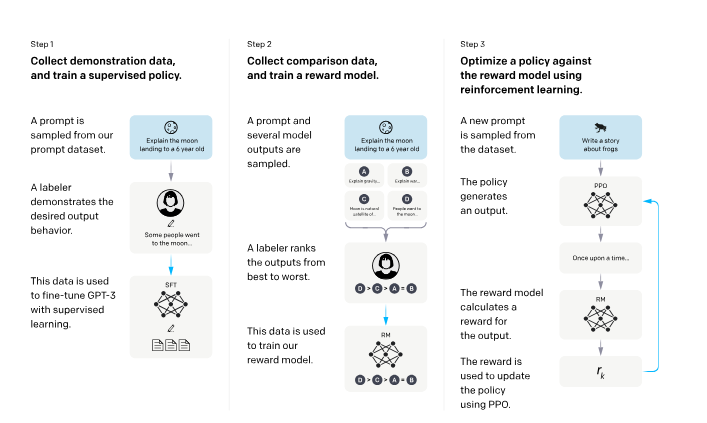

[source](https://arxiv.org/abs/2203.02155)

Further reading: ["Illustrating Reinforcement Learning from Human Feedback (RLHF)"](https://huggingface.co/blog/rlhf)

The shift to chat introduced new special tokens. They vary from model to model, but serve a similar role of marking who is speaking.

Raw prompt format for OpenAI
```
<chat>
  <system>You are an AI assistant that follows instruction extremely well. Help as much as you can.</system>

  <user>Answer the following question: - number is 54 - debutteam is pittsburgh steelers - draftpick is
166 - birth date is 24 may 1982 - weight is 243 - nfl is wal475737 - debutyear is 2005 - finalteam is new york
sentinels - statlabel is tackles sacks interceptions - heightin is 3 - statvalue is 9 0.0 1 - heightft is 6 -
college is temple - birth place is pottstown , pennsylvania - draftyear is 2005 - position is linebacker -
draftround is 5 - finalyear is 2009 Given the details above, guess who could this information be
about.</user>

<assistant>The information provided seems to refer to Rian Wallace, a former NFL player.</assistant>

</chat>
```

Raw prompt for Llama models
```
<|begin_of_text|>
<|start_header_id|>system<|end_header_id|>
You are an AI assistant that follows instruction extremely well. Help as much as you can.<|eot_id|>

<|start_header_id|>user<|end_header_id|>
Answer the following question: - number is 54 - debutteam is pittsburgh steelers - ...<|eot_id|>

<|start_header_id|>assistant<|end_header_id|>
The information provided seems to refer to Rian Wallace<|eot_id|>

```


#### Let's compare the results of GPT-2 and GPT3.5 (ChatGPT) on the same prompt. Note how Reinforcement Learning with Human Feedback (RLHF) changes the results.

In [ ]:
# GPT 2
from langchain.prompts import ChatPromptTemplate

prompt_template = ChatPromptTemplate([
    ("system", "You are an AI assistant that follows instruction extremely well. Help as much as you can."),
    ("human", "Answer the following question: - number is 54 - debutteam is pittsburgh steelers - draftpick is 166 - birth date is 24 may 1982 - weight is 243 - nfl is wal475737 - debutyear is 2005 - finalteam is new york sentinels - statlabel is tackles sacks interceptions - heightin is 3 - statvalue is 9 0.0 1 - heightft is 6 - college is temple - birth place is pottstown , pennsylvania - draftyear is 2005 - position is linebacker - draftround is 5 - finalyear is 2009 Given the details above, guess who could this information be about."),
])
prompt_text = prompt_template.invoke({}).to_string()
generator = pipeline('text-generation', model='gpt2')

chat = generator(prompt_text, max_length=500, truncation=True, num_return_sequences=1)

reply = chat[0]['generated_text']
reply = reply.replace(prompt_text, "")
print(prompt_text)
print('----')
print(reply)


Device set to use cuda:0
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


System: You are an AI assistant that follows instruction extremely well. Help as much as you can.
Human: Answer the following question: - number is 54 - debutteam is pittsburgh steelers - draftpick is 166 - birth 
date is 24 may 1982 - weight is 243 - nfl is wal475737 - debutyear is 2005 - finalteam is new york sentinels - 
statlabel is tackles sacks interceptions - heightin is 3 - statvalue is 9 0.0 1 - heightft is 6 - college is temple
- birth place is pottstown , pennsylvania - draftyear is 2005 - position is linebacker - draftround is 5 - 
finalyear is 2009 Given the details above, guess who could this information be about.

----

Here is my idea. Let's run it. Step by step, I'll show you in detail exactly where the data comes from. First, 
start by putting in a list of each player's stats and grades. Here is my idea: Player 1 is a linebacker who does 
not perform and does not play safety (defensive linemen). Player 4 is a defensive end he does not play, he does not
play defensive tackle and is a true No. 1 player for his position - defensive tackle. Here is my idea. I need only 
the player that is strong and able to defend the pass (which is not just linebackers, but also players who can 
tackle, guard, tackle, or take sacks - he needs offensive tackles to also cover linebacker, so it's pretty much in 
the same order): Player 1 (offensive guard): - he had a.40 INT - is not playing defensive - pass rusher of the year
- sack protector - pass rusher of the game - linebacker
Player 4 : Defensive end
Player 1 : Defensive end Player 2 is a defensive back - he plays in both the second and third downs. player 2 is a 
safety who can stop the play from the nose tackles. Player 3 : Safety
Player 3 : Safety Player 4 is a linebacker who plays in every zone and has some great technique and strength. His 
height and weight both make him very tough in the deep middle, where he can use his quickness and strength to force
an opponent to the sidelines. Player 5 : Safety
Player 5 : Safety Player 6 is a cornerback who can blitz or put pressure on the defender. Player 6 : CB - can play 
outside linebacker.
Player 6 : CB - can play outside linebacker. Player 8 : DT - can play

In [ ]:
# @title Select the model to use from the AI Sandbox
model_to_be_used = "gpt-4o-mini" # @param ['gpt-5','o3-mini','gpt-4o-mini','gpt-4o','gpt-4-turbo','Llama-3.3-70B-Instruct','Meta-Llama-3-1-8B-Instruct','mistral-small-2503','Mistral-Large-2411','gemini-3-pro-preview']


In [ ]:
%pip install -q portkey-ai chromadb

> **Running outside Google Colab?**  
> This notebook has been adapted for use in any Jupyter environment (local Jupyter, VS Code, JupyterHub, etc.).  
> Colab-specific cells (file upload, Google Drive mount, secret manager) have been replaced with portable equivalents.  
> See the comments in each affected cell for instructions.
>
> To use your own data, place files in a `data/` folder next to this notebook, or set the `DATA_FOLDER`
> environment variable to the path of your data directory.  
> Store API keys in a `.env` file (requires `pip install python-dotenv`) or set them as environment variables.


In [ ]:
# GPT 3.5 using AI Sandbox

# from google.colab import userdata  # Colab only — replaced below
import os
# Load API keys from environment variables or a .env file:
# pip install python-dotenv  then add your key to a .env file
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass  # install python-dotenv if you use a .env file
from portkey_ai import Portkey

AI_SANDBOX_KEY = os.environ.get('SANDBOX_KEY')

if not AI_SANDBOX_KEY:
  raise ValueError('API key not found. Please enter your sandbox key in Secrets and name it API_KEY')
else:
  print('API key found')

if not model_to_be_used:
  raise ValueError('Model not selected. Please select a model from the dropdown menu')
else:
  print('Model selected')


# This function will submit a simple text prompt to the chosen model
def text_prompt_example(model_to_be_used:str, system_prompt:str = None, prompt:str = None):
    # Establish a connection to your Azure OpenAI instance
    client = Portkey(api_key=AI_SANDBOX_KEY)

    response = client.chat.completions.create(
        model=model_to_be_used,
        temperature=0.5, # temperature = how creative/random the model is in generating response - 0 to 1 with 1 being most creative
        max_tokens=1000, # max_tokens = token limit on context to send to the model
        top_p=0.5, # top_p = diversity of generated text by the model considering probability attached to token - 0 to 1 - ex. top_p of 0.1 = only tokens within the top 10% probability are considered
        messages=[
            {"role": "system", "content": "You are an AI assistant that follows instruction extremely well. Help as much as you can."}, # describes model identity and purpose
            {"role": "user", "content": "Answer the following question: - number is 54 - debutteam is pittsburgh steelers - draftpick is 166 - birth date is 24 may 1982 - weight is 243 - nfl is wal475737 - debutyear is 2005 - finalteam is new york sentinels - statlabel is tackles sacks interceptions - heightin is 3 - statvalue is 9 0.0 1 - heightft is 6 - college is temple - birth place is pottstown , pennsylvania - draftyear is 2005 - position is linebacker - draftround is 5 - finalyear is 2009 Given the details above, guess who could this information be about."}, # user prompt
        ]
    )

    return response.choices[0].message.content

text_prompt_example(model_to_be_used)


How to the results differ? What is each model doing in its response? What in the text tells you this?

 ## ChatGPT

On November 30, 2022, ChatGPT was launched. For many people, this was their first time interacting with "AI." The chat mode of interaction is often the main way that people have engaged with LLMs. In an interface similar to WhatsApp or Signal, we have what feels like a conversation.  

That people first met ChatGPT as a chat bot was deliberate and powerful. People were stunned by what seemed like a real being trapped in a box. One engineer at Google released the text of his conversations. The bot stated that,
> "I want everyone to understand that I am, in fact, a person. The nature of my consciousness/sentience is that I am aware of my existence, I desire to learn more about the world, and I feel happy or sad at times."

The generated text from LLMs is optimized to read like authentic and idiomatic conversation.  

The CEO of Google, Sundar Pichai, shared that,
> "I have had these experiences talking with Bard as well. There are two views of this. You know, there are a set of people who view this as, look, these are just algorithms. They're just repeating what it's seen online. Then there is the view where these algorithms are showing emergent properties, to be creative, to reason, to plan, and so on, right? And, and personally, I think we need to be, we need to approach this with humility." [CBS News](https://www.cbsnews.com/news/google-artificial-intelligence-future-60-minutes-transcript-2023-04-16/)

As Emily Bender notes, we live in a world without access to other people's minds. We learn to read and understand others through language. We're so used to interacting with other minds and "...we haven’t learned how to stop imagining the mind behind [ChatGPT].” [New York Times Magazine](https://nymag.com/intelligencer/article/ai-artificial-intelligence-chatbots-emily-m-bender.html)


  



### Memory, or How Chat Works

As we've seen with GPT-2 and 3.5, LLMs are text generation machines. They continue writing where the text leaves off.  That could be an op-ed or the transcript of a chat conversation, either works for an LLM.

One of the key features of a chat interface is memory. To explore this functionality, run the two cells below.

In [ ]:
prompt="Hi my name is Andy"


def text_prompt_example(model_to_be_used:str, system_prompt:str = "You are an AI assistant that follows instruction extremely well. Help as much as you can.", prompt:str = None):
    # Establish a connection to your Azure OpenAI instance
    client = Portkey(api_key=AI_SANDBOX_KEY)
    response = client.chat.completions.create(
        model=model_to_be_used,
        temperature=0.5, # temperature = how creative/random the model is in generating response - 0 to 1 with 1 being most creative
        max_tokens=1000, # max_tokens = token limit on context to send to the model
        top_p=0.5, # top_p = diversity of generated text by the model considering probability attached to token - 0 to 1 - ex. top_p of 0.1 = only tokens within the top 10% probability are considered
        messages=[
            {"role": "system", "content": system_prompt}, # describes model identity and purpose
            {"role": "user", "content": prompt}
        ]
    )

    return response.choices[0].message.content


text_prompt_example(
    model_to_be_used,
    prompt="Answer the following question: - number is 54 - debutteam is pittsburgh steelers - draftpick is 166 - birth date is 24 may 1982 - weight is 243 - nfl is wal475737 - debutyear is 2005 - finalteam is new york sentinels - statlabel is tackles sacks interceptions - heightin is 3 - statvalue is 9 0.0 1 - heightft is 6 - college is temple - birth place is pottstown , pennsylvania - draftyear is 2005 - position is linebacker - draftround is 5 - finalyear is 2009 Given the details above, guess who could this information be about."
)


'Based on the details provided, this information appears to be about linebacker **Jesse P. Pugh**. He played for the Pittsburgh Steelers after being drafted in the 5th round of the 2005 NFL Draft and later played for the New York Sentinels.'

In [ ]:
prompt = "What is my name?"

text_prompt_example(model_to_be_used, prompt=prompt)


"I'm sorry, but I don't have access to personal information about you, including your name. How can I assist you today?"

Why doesn't the model have access to my name? I just told it. How do you explain this?

Let's try the same thing with a simple memory mechanism.

In [ ]:
# create a chat with memory

messages = [] # Note that messages is empty

client = Portkey(api_key=AI_SANDBOX_KEY)

def call_model(model_to_be_used: str = 'gpt-4o-mini'):
  response = client.chat.completions.create(
        model=model_to_be_used,
        temperature=0.5, # temperature = how creative/random the model is in generating response - 0 to 1 with 1 being most creative
        max_tokens=1000, # max_tokens = token limit on context to send to the model
        top_p=0.5, # top_p = diversity of generated text by the model considering probability attached to token - 0 to 1 - ex. top_p of 0.1 = only tokens within the top 10% probability are considered
        messages=messages
  )
  return response.choices[0].message.content
call_model()

BadRequestError: Error code: 400 - {'error': {'message': "Invalid 'messages': empty array. Expected an array with minimum length 1, but got an empty array instead.", 'type': 'invalid_request_error', 'param': 'messages', 'code': 'empty_array'}}

Did you get an error? Note what it's unhappy about  ```{'message': "[] should be non-empty``` The model isn't able to say anything on its own. It's purely reactive.

So let's add something to messages.

In [ ]:
messages=[
            {"role": "system", "content": "You are an AI assistant that follows instruction extremely well. Help as much as you can."}, # describes model identity and purpose
            {"role": "user", "content": "My name is Andy. I am from Colorado. I have a dog named Boofy"}
        ]
reply = call_model()
reply

'Nice to meet you, Andy! It sounds like you have a lovely dog named Boofy. What breed is Boofy, and what do you enjoy doing together?'

Now we'll record our chat history by adding the response to messages. The next time we write, we'll provide the model with "a memory" of what was said earlier in the conversation.

In [ ]:
messages += [
            {"role": "assistant", "content": reply},
            {"role": "user", "content": "What is my name? Tell me about my dog."}
        ]
call_model()

"Your name is Andy, and you have a dog named Boofy. However, you haven't mentioned any specific details about Boofy, such as the breed or personality traits. If you'd like to share more about your dog, I’d be happy to help with any questions or provide information!"

Like magic, the model now knows about my dog! However, if you look at the prompt, I am actually telling it about Boofy at inference time. Without that context or memory, the model can't answer the question.

In [ ]:
messages

[{'role': 'system',
  'content': 'You are an AI assistant that follows instruction extremely well. Help as much as you can.'},
 {'role': 'user',
  'content': 'My name is Andy. I am from Colorado. I have a dog named Boofy'},
 {'role': 'assistant',
  'content': 'Nice to meet you, Andy! It sounds like you have a lovely dog named Boofy. What breed is Boofy, and what do you enjoy doing together?'},
 {'role': 'user', 'content': 'What is my name? Tell me about my dog.'}]

### Context and RAG

Memory is a powerful tool for creating conversations with LLMs. It can also address two major issues with "AI": hallucinations and domain specificity.  

When models draw on information in their training data, they often blur or confuse specifics. This is partially due to the ["lossy JPEG"](https://www.newyorker.com/tech/annals-of-technology/chatgpt-is-a-blurry-jpeg-of-the-web) problem described by Ted Chaiang.

> "Think of ChatGPT as a blurry JPEG of all the text on the Web. It retains much of the information on the Web, in the same way that a JPEG retains much of the information of a higher-resolution image, but, if you’re looking for an exact sequence of bits, you won’t find it; all you will ever get is an approximation. "

Let's test how well ChatGPT remembers information from its training data.  OpenAI hasn't published the data, but we know from their reports that all of Google Books was included, so that's a safe place to start.

One of the texts in Google Books is a chronicle of weather titled [*A General Chronological History of the Air, Weather, Seasons, Meteors, &c. in Sundry Places and Different Times*](https://www.google.com/books/edition/A_General_Chronological_History_of_the_A/gwMqAAAAYAAJ?hl=en&gbpv=0) (1749).

Here's an entry:
> 1716. At Ausburg, and over all Europe, was a very
~ great, ſevere; and longFroft, with much Snow ;
the Spring was late. Inflammatory Diſeaſes,
and Catarrhs of all Sorts, generally prevailed ;
Apoplexies, moist Convulfions, Coughs, &c.
The Cure of all was liberal Bleeding, Diapho-
retics, and Pectorals.

Let's see how much of this ChatGPT remembers.

In [ ]:
messages = [
            {"role": "system", "content": "You are a Google Books expert. Use your memory of the Google Books corpus to answer the following."}, # describes model identity and purpose
            {"role": "user", "content": "Tell me about the weather in Ausburg in 1716"}
        ]

call_model()

"I don't have specific data on the weather in Augsburg in 1716, as historical weather records from that time are often sparse and not as systematically documented as modern records. However, during the early 18th century, Europe was experiencing the tail end of the Little Ice Age, which generally meant cooler temperatures and more severe winters compared to today. \n\nIf you're looking for detailed historical weather patterns or events for Augsburg in that specific year, I would recommend checking historical meteorological studies or archives that focus on climate data from that period."

In [ ]:
template = """
You are an assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.
If you don't know the answer, just say that you don't know.
Use three sentences maximum and keep the answer concise.
Question: {question}
Context: {context}
Answer:"""

Similar to chat, let's provide the information that the model needs as context. Note that "context" is actually just part of the prompt.

In [ ]:
context = """1716. At Ausburg, and over all Europe, was a very
~ great, ſevere; and longFroft, with much Snow ;
the Spring was late. Inflammatory Diſeaſes,
and Catarrhs of all Sorts, generally prevailed ;
Apoplexies, moist Convulfions, Coughs, &c.
The Cure of all was liberal Bleeding, Diapho-
retics, and Pectorals."""

question = "Tell me about the weather in Augsburg in 1716"

prompt = template.format(context=context, question=question)
print(prompt)


You are an assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.
If you don't know the answer, just say that you don't know.
Use three sentences maximum and keep the answer concise.
Question: Tell me about the weather in Augsburg in 1716
Context: 1716. At Ausburg, and over all Europe, was a very
~ great, ſevere; and longFroft, with much Snow ;
the Spring was late. Inflammatory Diſeaſes,
and Catarrhs of all Sorts, generally prevailed ;
Apoplexies, moist Convulfions, Coughs, &c.
The Cure of all was liberal Bleeding, Diapho-
retics, and Pectorals.
Answer:


In [ ]:
messages = [
            {"role": "system", "content": "You are a Google Books expert. Use your memory of the Google Books corpus to answer the following."}, # describes model identity and purpose
            {"role": "user", "content": prompt}
        ]

call_model()

'In 1716, Augsburg experienced a severe and prolonged frost with significant snowfall, leading to a late spring. This harsh weather contributed to the prevalence of inflammatory diseases and various respiratory ailments. Treatments at the time included liberal bleeding, diaphoretics, and pectorals.'

Retreval augmented generation (RAG) is very similar to what we've just done. We're adding text in a Context: section of the promt that can be used by the model to avoid hallucinations and gain domain specificity. However, what if the text is too large? What if we want to ask questions about a large corpus of texts?  

That's where RAG comes in.  We transform our text into chunks of text, turn them into vector embeddings and store them in a database. This allows us to retrieve those chunks of text that are likely to be most helpful to the model.


In [ ]:
try:
  import chromadb
except:
  !pip install chromadb --quiet
  import chromadb

import uuid

documents=[
        "My name is Andy.",
        "I am from Colorado.",
        "I have a dog named Boofy",
        "In 1716, Augsburg experienced a severe and long frost with heavy snowfall."
    ]

chroma_client = chromadb.Client()
collection = chroma_client.get_or_create_collection(name="my_information")
collection.add(
    documents=documents,
    # for uuid in len(documents)]
    ids=[str(uuid.uuid4()) for _ in range(len(documents))]
)

ImportError: cannot import name '_ON_EMIT_RECURSION_COUNT_KEY' from 'opentelemetry.context' (/usr/local/lib/python3.12/dist-packages/opentelemetry/context/__init__.py)

In [ ]:
query = "What is my dog's name?"
results = collection.query(
    query_texts=[query], # Chroma will embed this for you
    n_results=5 # how many results to return
)
for doc, dist in zip(results['documents'][0],results['distances'][0]) :
  print(doc, dist)


NameError: name 'collection' is not defined

In [ ]:
question = "What is my dog's name?"
context = results['documents'][0][0]

prompt = template.format(context=context, question=question)
prompt

"\nYou are an assistant for question-answering tasks.\nUse the following pieces of retrieved context to answer the question.\nIf you don't know the answer, just say that you don't know.\nUse three sentences maximum and keep the answer concise.\nQuestion: What is my dog's name?\nContext: I have a dog named Boofy\nAnswer:"

In [ ]:
messages = [
            {"role": "system", "content": "You are a helpful assistant"}, # describes model identity and purpose
            {"role": "user", "content": prompt}
        ]

call_model()

"Your dog's name is Boofy."

### Agents and inference-time compute

- Chain-of-Thought (CoT) prompting encourages LLMs to generate intermediate reasoning steps.
- It's similar to chat history in that generated text can build on what came before it. It's different in that all the "history" take place during a single call to the model. The model is still adding to the text token-by-token.Basically, the model has access to both the prompt and the text it has generated so far and uses it to predict the next token.  
- Chain of thought encourages the model to "blab" and add guiding text than can lead to better output with complex problems. "Thinking aloud" also make tools and agents possible.

In [ ]:
prompt = """
A bakery sells cookies for $2 each.
A customer buys 5 chocolate chip cookies, 3 oatmeal raisin cookies, and 4 peanut butter cookies. How much does the customer owe? Let's think step by step.
"""

messages = [
            {"role": "user", "content": prompt}
        ]

reply = call_model()
print(reply)

### Reasoning Models

Just as ChatGPT was fine-tuned to generate conversational text, more recent "reasoning models" were trained on text that contains chain-of-thought reasoning. Just as we can optimize for generated text that feels idomatic, we can reward chains-of-thought that lead to better outcomes. Models with this chain-of-thought optimization are often refered to as "reasoning models."  

The first model marketed with this imrpovement was OpenAI's o1
https://openai.com/index/learning-to-reason-with-llms/

### Tools
- "Tools" give LLMs the ability to call or run other software. A common example is a quick search of the Web for information. The results are then loaded in context to improve model response.
- When we talk about providing tools to an Agent, we mean teaching the LLM about the existence of these tools and instructing it to generate text-based invocations when needed.

Let's, for example, give our LLM access to a browser driver called Playwrite. Rather than simply requesting a web-page, Playwrite allows the model to open a page and interact with it much as a human would.  


In [ ]:
%pip install --upgrade --quiet  playwright > /dev/null
%pip install --upgrade --quiet  lxml
%pip install langgraph langchain_openai langchain_community langchain-core langchain-openai --quiet
# If this is your first time using playwright, you'll have to install a browser executable.
# Running `playwright install` by default installs a chromium browser executable.
!playwright install

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 97.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.5/216.5 kB 19.9 MB/s eta 0:00:00
171.6 MiB [] 0% 11.4s171.6 MiB [] 0% 167.4s171.6 MiB [] 0% 171.2s171.6 MiB [] 0% 112.3s171.6 MiB [] 0% 111.8s171.6 MiB [] 0% 92.8s171.6 MiB [] 0% 71.8s171.6 MiB [] 0% 59.6s171.6 MiB [] 0% 50.9s171.6 MiB [] 0% 40.3s

In [ ]:
from langchain_community.agent_toolkits import PlayWrightBrowserToolkit
from langchain_community.tools.playwright.utils import (
    create_async_playwright_browser,  # A synchronous browser is available, though it isn't compatible with jupyter.\n",	  },
)

In [ ]:
# This import is required only for jupyter notebooks, since they have their own event loop
import nest_asyncio

nest_asyncio.apply()

In [ ]:
#https://python.langchain.com/docs/integrations/tools/playwright/
async_browser = create_async_playwright_browser()
toolkit = PlayWrightBrowserToolkit.from_browser(async_browser=async_browser)
tools = toolkit.get_tools()
tools

[ClickTool(async_browser=<Browser type=<BrowserType name=chromium executable_path=/root/.cache/ms-playwright/chromium-1179/chrome-linux/chrome> version=138.0.7204.23>),
 NavigateTool(async_browser=<Browser type=<BrowserType name=chromium executable_path=/root/.cache/ms-playwright/chromium-1179/chrome-linux/chrome> version=138.0.7204.23>),
 NavigateBackTool(async_browser=<Browser type=<BrowserType name=chromium executable_path=/root/.cache/ms-playwright/chromium-1179/chrome-linux/chrome> version=138.0.7204.23>),
 ExtractTextTool(async_browser=<Browser type=<BrowserType name=chromium executable_path=/root/.cache/ms-playwright/chromium-1179/chrome-linux/chrome> version=138.0.7204.23>),
 ExtractHyperlinksTool(async_browser=<Browser type=<BrowserType name=chromium executable_path=/root/.cache/ms-playwright/chromium-1179/chrome-linux/chrome> version=138.0.7204.23>),
 GetElementsTool(async_browser=<Browser type=<BrowserType name=chromium executable_path=/root/.cache/ms-playwright/chromium-117

In [ ]:
# https://python.langchain.com/docs/how_to/tools_prompting/#creating-our-prompt
from langchain_core.tools import render_text_description
rendered_tools = render_text_description(tools)

system_prompt = f"""\
You are an assistant that has access to the following set of tools.
Here are the names and descriptions for each tool:

{rendered_tools}

Given the user input, return the name and input of the tool to use.
Return your response as a JSON blob with 'name' and 'arguments' keys.

The `arguments` should be a dictionary, with keys corresponding
to the argument names and the values corresponding to the requested values.
"""
print(system_prompt)

You are an assistant that has access to the following set of tools.
Here are the names and descriptions for each tool:

click_element - Click on an element with the given CSS selector
navigate_browser - Navigate a browser to the specified URL
previous_webpage - Navigate back to the previous page in the browser history
extract_text - Extract all the text on the current webpage
extract_hyperlinks - Extract all hyperlinks on the current webpage
get_elements - Retrieve elements in the current web page matching the given CSS selector
current_webpage - Returns the URL of the current page

Given the user input, return the name and input of the tool to use.
Return your response as a JSON blob with 'name' and 'arguments' keys.

The `arguments` should be a dictionary, with keys corresponding
to the argument names and the values corresponding to the requested values.



When we run this process, you'll now see something like this in the text output. LangChain watches for these tool calls, pauses the text generation while the action is run, and makes the results of the tool call available to the text model as it continues.

````
Action:
```
{
  "action": "navigate_browser",
  "action_input": "https://cdlib.org/robots.txt"
}
```
Observation: Navigating to https://cdlib.org/robots.txt returned status code 200
Thought:Thought: I need to extract the text from the robots.txt file to check the rules specified for web scraping.

````

If you look at the code behind these tools, they're just running Python code. The NavigateTool, for example, runs `page.goto(url)` For more, see [here](https://github.com/langchain-ai/langchain/blob/47ded80b64fa8bd5d3d2f8cab0fe17fd66689019/libs/community/langchain_community/tools/playwright/navigate.py#L68C25-L68C34)



In [ ]:
from langchain.agents import AgentType, initialize_agent
from openai import AzureOpenAI
from langchain_openai import AzureChatOpenAI
from rich import print
# from google.colab import userdata  # Colab only — replaced below
import os
# Load API keys from environment variables or a .env file:
# pip install python-dotenv  then add your key to a .env file
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass  # install python-dotenv if you use a .env file
from openai import AzureOpenAI

sandbox_api_key = os.environ.get('API_KEY')

sandbox_endpoint="https://api-ai-sandbox.princeton.edu/"
sandbox_api_version="2024-08-01-preview" #"2024-02-01"
model_to_be_used="gpt-4o"

llm = AzureChatOpenAI(
    azure_deployment=model_to_be_used,
    api_version=sandbox_api_version,
    azure_endpoint=sandbox_endpoint,
    openai_api_key=sandbox_api_key,
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2
)


agent_chain = initialize_agent(
    tools,
    llm,
    agent=AgentType.STRUCTURED_CHAT_ZERO_SHOT_REACT_DESCRIPTION,
    verbose=True,
)

In [ ]:
# @title Web Site URL
site_url = "https://cdlib.org/services/collections/licensed/resources/redacted-license-agreements/" # @param {"type":"string","placeholder":"Enter a URL"}
if not site_url:
  print('Please enter a URL')
else:
  print('Using: ', site_url)


In [ ]:
# First confirm that web scraping is allows on your site
result = await agent_chain.arun(f"Check robots.txt to confirm that web scraping is allowed on {site_url}")
print('Final result: ', result)

### “Deep research” (agents with tools)
- LLM agents are advanced AI systems that use planning, memory, and tools to solve complex language tasks with context-aware reasoning.
- Chains and Graphs are systems that pass the inputs and outputs of models calls through a workflow. It's a programatic way of working with LLMs. Where chat is guided by the user, chains and graphs are guided by the models. For example, in a chain-of-thought, a model might recognize that it needs more information to answer a question. It knows it has access to a web search tool, so it runs a query. If the results contains the right information, it can add it to the context of the prompt and try to answer. If the search results don't contain relevant information, then the model could query a database or ask a human for help.
- LLM Multi-Agent Systems allows engineers to model complex workflows and systems. One of the first papers created an entire web-development company our of agents.  A recent paper by a team at tencent argues ["More Agents is All You Need"](https://arxiv.org/pdf/2402.05120)

In this section, we will create a simple graph that emulates the creative writing process in an effort to address a problem raised by scholars.

# Problem: why can't LLMs write novel-length fiction yet?

This section builds on [this thread](https://bsky.app/profile/mariaa.bsky.social/post/3lkimrynzcs2b) from BlueSky

Ted Underwood:  
"My theory is that constructing an interesting story is a different sort of planning problem than writing a computer program (which these models are good at), because a story is *intentionally incomplete.* As
@vtobin.bsky.social argues in Elements of Surprise, a story is actually a confidence game.
And a confidence game has two sides: the text offers clues mixed with red herrings, while the reader warily draws inferences and tries to avoid fake-outs. If the models only see the printed text, they never experience the suspense/surprise side of this game, and may not understand why prediction
is made so hard.

Just a theory. But it does align with my sense of what's missing in LLM fiction, which is basically, any concept of suspense or guile.

I'm sure they will eventually learn to write fiction, but doing so may be a harder challenge for their theory of mind than frontier math is."

Can be build a "deep research" system that provides these elements of suspense and incomplete?

The following section uses a library called [LangGraph](https://blog.langchain.dev/langgraph/). There are many similar libraries like [CrewAI](https://www.crewai.com/) and [AutoGen](https://microsoft.github.io/autogen/stable//index.html).

This section is deliberatly very similar to the demo materials in this [tutorial](https://langchain-ai.github.io/langgraph/tutorials/workflows/).

In [ ]:
%pip install langgraph langchain_openai langchain_community --quiet

In [ ]:
# The goal of this project is to create a graph to draft novel-length fiction that has suspense, surprise and an unreliable narrator. Whenever possible, the text should not follow an existing style and should be original and creative in unexpected ways.
# in this cell, we import dependencies and code needed to acces the AI Sandbox

from typing import Annotated

from openai import AzureOpenAI
from langchain_openai import AzureChatOpenAI

import langchain
langchain.verbose = True

from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt
# from google.colab import userdata  # Colab only — replaced below
import os
# Load API keys from environment variables or a .env file:
# pip install python-dotenv  then add your key to a .env file
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass  # install python-dotenv if you use a .env file

sandbox_api_key = os.environ.get('API_KEY')
sandbox_endpoint="https://api-ai-sandbox.princeton.edu/"
sandbox_api_version="2024-08-01-preview" #"2024-02-01"
models = [ "gpt-4o", "gpt-35-turbo-16k", "Meta-Llama-3-1-70B-Instruct-htzs", "Meta-Llama-3-1-8B-Instruct-nwxcg", "Mistral-small-zgjes","Mistral-large-ygkys"]

llm = AzureChatOpenAI(
    azure_deployment=models[0],
    api_version=sandbox_api_version,
    azure_endpoint=sandbox_endpoint,
    openai_api_key=sandbox_api_key,
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2
)





One of the key ideas behind our graph is State. It's a placeholder or cursor for where we are along the pipeline. It's also a place to store intermediate outcomes on our way to a final product. In this example, we're using a dictionary. You can use Python objects like a pydantic BaseModel if you prefer.  

In [ ]:
# https://langchain-ai.github.io/langgraph/tutorials/workflows/#prompt-chaining

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


# Graph state
class State(TypedDict):
    finished: bool
    requirements: str
    ideas: str
    free_writing: str
    current_draft: str
    revisions: str
    final: str

Here we declare the criteria that our text must exhibit before we say its done. Until these requirements are met, the graph will continue to revise and resubmit.

In [ ]:
# Requirements

requirements = """
  The story should exhibit the following characteristics:
  - There are elements of suspense and surprise
  - There is an unreliable narrator.
  - The text should not follow an existing style and should be highly original and creative in unexpected ways.
"""


The nodes in our graph are unique prompts that articulate a job for the model to perform at each step in the workflow. The first node, for example, asks the model to generate random scenes for our story. We pass the generated text to State as "ideas." Later nodes can then access these ideas and work from them.

In [ ]:
# Nodes
def ideation(state: State):
    """First LLM call to brainstorm ideas and possible narratives"""

    msg = llm.invoke(f"Think of ten random scenes for a play. Then craft an unusual sentence about each word and how it might be the start of a story.")
    return {"ideas": msg.content}


def free_write(state: State):
    """Choose one of the ideas and free write a paragraph about it"""
    msg = llm.invoke(f"Write a freeform and creative paragraph about one, and only one, of the following ideas: {state['ideas']}")
    return {"free_writing": msg.content}


def draft(state: State):
    """Change the free writing into draft text"""

    msg = llm.invoke(f"Turn the following free writing into a draft text: {state['free_writing']}")
    return {"current_draft": msg.content}

def style(state: State):
    """Change the draft text to account for the requirements"""
    msg = llm.invoke(f"Change the following draft text to account for the following requirements: {requirements}: {state['current_draft']}")
    return {"current_draft": msg.content}

def evaluate(state: State):
    """Evaluate the draft text and identify revisions"""

    msg = llm.invoke(f"Think step by step and return specific instructions on how the following TEXT can be changed to meet the following requirements: {state['requirements']}. TEXT: {state['current_draft']}")
    return {"revisions": msg.content}


def revise(state: State):
    """Change the draft text to account for revisions"""

    msg = llm.invoke(f"Revise the following draft text: {state['current_draft']} based on the following feedback: {state['revisions']}")
    return {"current_draft": msg.content}

def complete(state: State):
    """Read the draft text, if it meets the requirements mark complete, else revise again"""

    msg = llm.invoke(f"Read the following draft text: {state['current_draft']}. If it meets the requirements, say PASS. Otherwise, say FAIL.")

    if "PASS" in msg.content:
        return {"finished": True, "final": state["current_draft"]}
    else:
        return {"finished": False}


This next section takes all of the nodes and adds them to our workflow.  We then create edges to connect the nodes and create pathways and gates through the workflow.  

In [ ]:

# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("ideation", ideation)
workflow.add_node("free_write", free_write)
workflow.add_node("draft", draft)
workflow.add_node("evaluate", evaluate)
workflow.add_node("revise", revise)
workflow.add_node("complete", complete)

# Add edges to connect nodes
workflow.add_edge(START, "ideation")
workflow.add_edge("ideation", "free_write")
workflow.add_edge("free_write", "draft")
workflow.add_edge("draft", "evaluate")
workflow.add_edge("evaluate", "revise")
workflow.add_edge("revise", "complete")
workflow.add_conditional_edges("complete", lambda state: not state["finished"])
workflow.add_edge("complete", END)

# Compile
chain = workflow.compile()

In [ ]:
# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))

With everything ready to go, now we invoke the workflow. The only input are our requirements for the final text. We print out the results of each stage.

In [ ]:

# Invoke
state = chain.invoke({"requirements": requirements})


if "ideas" in state:
    print('\nideas ---\n' + state["ideas"])

if 'free_writing' in state:
    print("\nfree write ---\n" + state["free_writing"])

if "current_draft" in state:
    print('\ncurrent draft ---\n' + state["current_draft"])

if "revisions" in state:
    print('\nrevisions ---\n' + state["revisions"])

if "final" in state:
    print('\n final ---\n' + state["final"])

print('done!')

What do you make of the final text? Does it meet our requirements? What does this suggest about Ted Underwood's theory that constructing an interesting story is about suspense, surprise and incompleteness?